In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math
import networkx as nx
import random

from coppeliasim_zmqremoteapi_client import RemoteAPIClient 


def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])

In [ ]:
def mapa(image_caminho,escala_imagem,tamanho_cell):

    # Invertendo os valores para visualizacao (Branco - 0, Preto - 1)

    img = mpimg.imread(image_caminho).astype(float)

    if img.ndim == 3:
        img = img[:, :, 0]

    img = 1 - img

    # Apenas para garantir que so teremos esses dois valores
    threshold = 0.5
    img[img > threshold] = 1
    img[img<= threshold] = 0

    # Dimensoes do mapa informado em metros (X, Y)
    map_dims = np.array(escala_imagem)

    # Escala Pixel/Metro
    sy, sx = img.shape[:2] / map_dims

    # Tamanho da celula do nosso Grid (em metros)
    cell_size = tamanho_cell

    rows, cols = (map_dims / cell_size).astype(int)
    grid = np.zeros((rows, cols))

    # Preenchendo o Grid
    # Cada celula recebe o somatorio dos valores dos Pixels
    for r in range(rows):
        for c in range(cols):
            
            xi = int(c*cell_size*sx)
            xf = int(xi + cell_size*sx)
            
            yi = int(r*cell_size*sy)
            yf = int(yi + cell_size*sy)
                        
            grid[r, c] = np.sum(img[yi:yf,xi:xf])
            
    # Binarizando as celulas como ocupadas (1) ou Nao-ocupadas (0)       
    grid[grid > threshold] = 1
    grid[grid<= threshold] = 0   



    return grid


In [6]:
grid = mapa('../mapas_meus/mapa1_invertido_extend.png',(100,100),(1))

RRT: caminho encontrado em iteração 176, tempo 0.01s


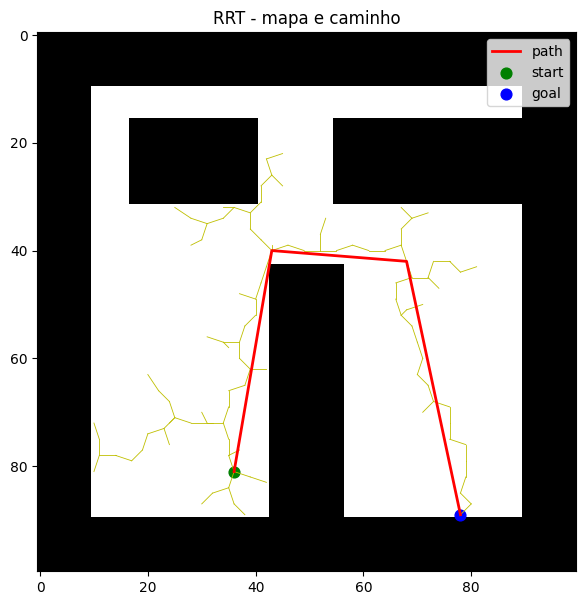

In [ ]:
class Node:
    def __init__(self, coord, parent=None):
        self.coord = coord
        self.parent = parent

def dist(a, b):
    return math.hypot(a[0]-b[0], a[1]-b[1])

def sample_free(rows, cols, goal, goal_sample_rate=0.05):
    if random.random() < goal_sample_rate:
        return goal
    return (random.randint(0, rows-1), random.randint(0, cols-1))

def nearest(nodes, sample):
    best_idx = 0
    best_d = float('inf')
    for i, n in enumerate(nodes):
        d = dist(n.coord, sample)
        if d < best_d:
            best_d = d
            best_idx = i
    return best_idx

def steer(from_coord, to_coord, step_size):
    d = dist(from_coord, to_coord)
    if d <= step_size:
        return to_coord
    else:
        theta = math.atan2(to_coord[0]-from_coord[0], to_coord[1]-from_coord[1])  
        new_r = from_coord[0] + step_size * math.sin(theta)
        new_c = from_coord[1] + step_size * math.cos(theta)
        
        return (int(round(new_r)), int(round(new_c)))

def collision_free(grid, a, b, step=0.5):
    a_r, a_c = a
    b_r, b_c = b
    length = dist(a, b)
    if length == 0:
        # verificar celula
        r, c = int(round(a_r)), int(round(a_c))
        if 0 <= r < grid.shape[0] and 0 <= c < grid.shape[1]:
            return grid[r, c] == 0
        return False
    n_samples = max(int(math.ceil(length / step)), 1)
    for i in range(n_samples+1):
        t = i / n_samples
        r = a_r + (b_r - a_r) * t
        c = a_c + (b_c - a_c) * t
        ri, ci = int(round(r)), int(round(c))
        if not (0 <= ri < grid.shape[0] and 0 <= ci < grid.shape[1]):
            return False
        if grid[ri, ci] == 1:
            return False
    return True

def reconstruct_path(node):
    path = []
    cur = node
    while cur is not None:
        path.append(cur.coord)
        cur = cur.parent
    return path[::-1]


def rrt_planner(grid, start, goal, max_iter, step_size, goal_sample_rate, visualize, smoothing_iters):

    rows, cols = grid.shape
    nodes = [Node(start, None)]

    found = False
    goal_node = None
    start_time = time.time()

    for it in range(max_iter):
        sample = sample_free(rows, cols, goal, goal_sample_rate=goal_sample_rate)
        nearest_idx = nearest(nodes, sample)
        nearest_node = nodes[nearest_idx]
        new_coord = steer(nearest_node.coord, sample, step_size)

        # checar limites e colisoes
        if not (0 <= new_coord[0] < rows and 0 <= new_coord[1] < cols):
            continue
        if grid[new_coord[0], new_coord[1]] == 1:
            continue
        if not collision_free(grid, nearest_node.coord, new_coord, step=0.5):
            continue

        new_node = Node(new_coord, nearest_node)
        nodes.append(new_node)

        # checar se chegou no goal (dentro de step_size ou colisao-free para goal)
        if dist(new_coord, goal) <= step_size and collision_free(grid, new_coord, goal, step=0.5):
            goal_node = Node(goal, new_node)
            nodes.append(goal_node)
            found = True
            print(f"RRT: caminho encontrado em iteração {it}, tempo {time.time()-start_time:.2f}s")
            break

    # reconstroi caminho
    path_coords = reconstruct_path(goal_node)

    # tenta juntar pares distantes se colisao-free
    def shortcut(path_coords, iters=smoothing_iters):
        if len(path_coords) <= 2:
            return path_coords
        for _ in range(iters):
            if len(path_coords) <= 2:
                break
            i = random.randint(0, len(path_coords)-2)
            j = random.randint(i+1, len(path_coords)-1)
            if j == i+1:
                continue
            if collision_free(grid, path_coords[i], path_coords[j], step=0.5):
                # remove os pontos entre i e j
                new_path = path_coords[:i+1] + path_coords[j:]
                path_coords = new_path
        return path_coords

    path_coords = shortcut(path_coords, smoothing_iters)

    
    pos = {}
    path = []
    for i, (r, c) in enumerate(path_coords):
        pos[i] = (int(c), int(r))
        path.append(i)

    if visualize:
        plt.figure(figsize=(7,7))
        plt.title("RRT - mapa e caminho")
        plt.imshow(grid, origin='upper', cmap='gray_r')
        # plot tree
        for n in nodes:
            if n.parent is not None:
                y0, x0 = n.parent.coord
                y1, x1 = n.coord
                plt.plot([x0, x1], [y0, y1], '-y', linewidth=0.6)
        # plot path
        ys = [p[0] for p in path_coords]
        xs = [p[1] for p in path_coords]
        plt.plot(xs, ys, '-r', linewidth=2, label='path')
        plt.scatter([start[1]], [start[0]], c='green', s=60, label='start')
        plt.scatter([goal[1]], [goal[0]], c='blue', s=60, label='goal')
        plt.legend()
        plt.show()

    return pos, path, nodes



# (79,80)  
# (13,29)

# (42,20) 
# (13,25)

# (14,18) 
# (68,63)

# (72,87) 
# (12,87)

# (81,36)
# (89,78)


#MAPA 1
# start_node = (11,11)
# end_node  = (79,80)

#MAPA 2
start_node =(81,36) 
end_node =  (89,78)

grid = mapa('../mapas_meus/mapa1_invertido_extend.png',(100,100),(1))

# RRT
pos, path, nodes = rrt_planner(grid, start_node, end_node, 12000, 3, 0.05, True, smoothing_iters= 200)



In [ ]:
def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = (x_px - img_size/2) * scale
        y_world = -(y_px - img_size/2) * scale
        return x_world, y_world




pos_world = {node: pixel_to_world(x, y, 100, 10) for node, (x, y) in pos.items()}


L = 0.135
r = 0.040

Mdir = np.array([
        [-r/np.sqrt(3),     0,        r/np.sqrt(3)],
        [r/3,            (-2*r)/3,    r/3],
        [r/(3*L),         r/(3*L),    r/(3*L)]
])


client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)

# posicao inicial = primeiro no do path
start_node = path[0]
start_pos_world = pos_world[start_node]
start_pos_sim = [start_pos_world[0], start_pos_world[1], 0.04]
start_ori_sim = [0, 0, np.deg2rad(90)]


robotname = 'robotino'
robotHandle = sim.getObject('/' + robotname)

wheel1 = sim.getObject(f'/{robotname}/wheel0_joint')
wheel2 = sim.getObject(f'/{robotname}/wheel1_joint')
wheel3 = sim.getObject(f'/{robotname}/wheel2_joint')
  

# Parar a simulacao se estiver executando
initial_sim_state = sim.getSimulationState()
if initial_sim_state != 0:
    sim.stopSimulation()
    time.sleep(1)

sim.startSimulation()
sim.setObjectPosition(robotHandle, sim.handle_world, start_pos_sim)
sim.setObjectOrientation(robotHandle, sim.handle_world, start_ori_sim)
sim.step()


# Estado inicial
q = np.array([start_pos_sim[0], start_pos_sim[1], start_ori_sim[2]])

print("Iniciando o caminho")

# Caminhos a ser seguidos
waypoints = [pos_world[node] for node in path]
target_index = 0
tolerance = 0.2



# loop principal de seguimento de waypoints
while target_index < len(waypoints):

    dt = sim.getSimulationTimeStep()
    target = np.array(waypoints[target_index])
    pos_sim = sim.getObjectPosition(robotHandle, sim.handle_world)
    q[:2] = pos_sim[:2]

    # Erro no referencial do mundo
    erro = target - q[:2]
    dist = np.linalg.norm(erro)

    # Controlador proporcional
    vx_world = 0.7 * erro[0]
    vy_world = 0.7 * erro[1]

    # Limita velocidades
    vx_world = np.clip(vx_world, -0.3, 0.3)
    vy_world = np.clip(vy_world, -0.3, 0.3)

    # Converte velocidade do mundo 
    v_body = Rz(-start_ori_sim[2]) @ np.array([vx_world, vy_world, 0.04])


    # vz_body e descartado por ser 0
    vx_body, vy_body , vz_body = v_body
    w = 0.0  # sem rotação

    # Calcula velocidades das rodas
    qdot = np.array([vx_body, vy_body, w])

    Minv = np.linalg.pinv(Mdir)
    u = Minv @ qdot  # usa cinematica inversa para gerar rodas

    # Envia velocidades
    sim.setJointTargetVelocity(wheel1, u[0])
    sim.setJointTargetVelocity(wheel2, u[1])
    sim.setJointTargetVelocity(wheel3, u[2])

    v = Mdir @ u
    q[0] += v[0] * dt
    q[1] += v[1] * dt
    q[2] += v[2] * dt

    # Avança um passo
    sim.step()

    # Verifica se chegou
    if dist < tolerance:
        print(f"Chegou em {path[target_index]} -> indo para o proximo ponto")
        target_index += 1


print("Caminho concluido! Parando robo...")
for w in [wheel1, wheel2, wheel3]:
    sim.setJointTargetVelocity(w, 0)

posi_final = sim.getObjectPosition(robotHandle, sim.handle_world)
print("Posicao final (SIM):", posi_final)
sim.stopSimulation()
print("Programa finalizado.")


Iniciando o caminho
Chegou em 0 -> indo para o proximo ponto
Chegou em 1 -> indo para o proximo ponto
Chegou em 2 -> indo para o proximo ponto
Chegou em 3 -> indo para o proximo ponto
Caminho concluido! Parando robo...
Posicao final (SIM): [2.879508584936867, -3.7294593954566735, 0.038923884904981644]
Programa finalizado.
